In [1]:
import numpy as np
import torch
from matplotlib import pyplot as plt
import random

from components.broadcast_components.WZ_models.WZ_quantizer import WZQuantizer
from components.broadcast_components.WZ_models.wz_quant_RNN import PL_EncoderDecoder_RNN

In [2]:
torch.set_float32_matmul_precision('medium')
import logging

logging.getLogger("pytorch_lightning").setLevel(logging.WARNING)
import warnings

warnings.filterwarnings("ignore", message="Starting from v1.9.0, `tensorboardX` has been removed")
warnings.filterwarnings("ignore", message="You defined a `validation_step` but have no `val_dataloader`")
warnings.filterwarnings("ignore", message="Consider setting `persistent_workers=True` in 'train_dataloader'")
warnings.filterwarnings("ignore", message="The 'val_dataloader' does not have")

random.seed(101)
torch.manual_seed(101)
np.random.seed(101)

In [3]:
# noise = np.random.normal(0, np.sqrt(1), 10_000_000, ).astype(np.float32)
# x = np.random.normal(0, np.sqrt(0.01), 10_000_000, ).astype(np.float32)
# y = noise + x
# side_info_data = [x.copy()]

# ------------------------------------------------------

x = np.random.random(10_000_000, ).astype(np.float32)*2-1
y = x + (np.random.random(10_000_000, ).astype(np.float32)*2-1)*0.25
side_info_data = [x.copy()]

near zero vales:1.00%


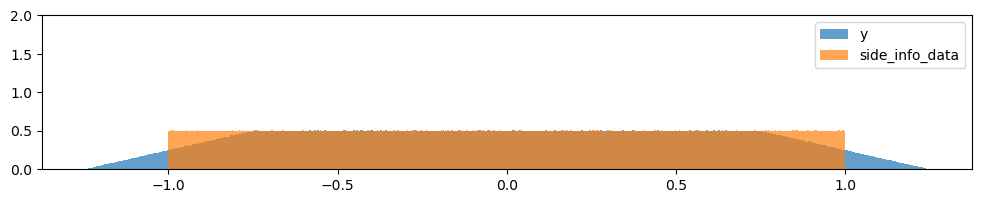

In [4]:
plt.figure(figsize=(12, 2))
plt.hist(y, alpha=0.7, bins=500, density=True, label='y')
if len(side_info_data):
    plt.hist(side_info_data[0], bins=500, alpha=0.7, density=True, label='side_info_data')
plt.ylim(0, 2)
print(f'near zero vales:{sum(np.abs(y)<0.01)/len(y)*100:.2f}%')
plt.legend()
plt.show()

In [6]:
wz_model = PL_EncoderDecoder_RNN(inp_dim=1, side_info_size=len(side_info_data), num_planes=3,
                                 bins_per_plane=2, lr=1e-3, marginal=False).to(torch.float32)
wz_quantizer = WZQuantizer(wz_model, train_sample_size=200_000, count_side_info_data=len(side_info_data), enable_progress_bar=True)
wz_quantizer.train_model(y, side_info_data, epoch=50, batch_size=10_000)

        - training wz model


Training: |          | 0/? [00:00<?, ?it/s]

In [7]:
bins, temp = wz_quantizer.encoding_process(y)
bins = bins.numpy()
recons = wz_quantizer.decoding_process(bins, side_info_data, temp)

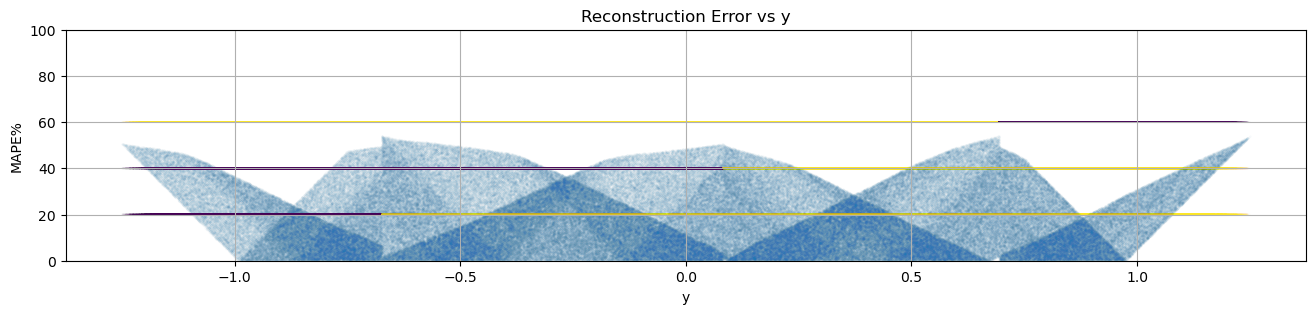

In [8]:
temp = np.argsort(y[:500_000])
plt.figure(figsize=(16, 3))
plt.scatter(y[temp], 100*np.abs((y[temp] - recons[temp]) / np.mean(np.abs(y[temp]))), s=0.1, alpha=0.05)
for i in range(len(bins)):
    plt.scatter(y[temp], [i*20+20]*len(temp), s=0.1, alpha=0.05, c=bins[i][temp]*20)
plt.ylim(0, 100)
plt.xlabel('y')
plt.ylabel('MAPE%')
plt.title('Reconstruction Error vs y')
plt.grid()
plt.show()

In [9]:
prior, _ = wz_quantizer.get_prior_and_softcodes(y, side_info_data)
prior = prior.numpy().astype(np.float64)

In [10]:
from components.broadcast_components.compressor.rans_coding import rans_encode, rans_decode

def get_rans_info(cond_probs_vec, symbols_vec):
    '''

    :param cond_probs_vec: The conditional probabilities of the symbols, shape (N, p) with p the number of possible symbols
    :param symbols_vec: the index of the symbols, shape (N)
    '''

    # the marginal probs is the likelyhood of each symbol in the entire data
    temp = np.bincount(symbols_vec, minlength=len(cond_probs_vec[0]))/len(symbols_vec)
    marg_probs_vec = np.array([temp]*len(symbols_vec))

    temp = (np.arange(len(symbols_vec)),symbols_vec)
    theor_marg_rate = -np.mean(np.log2(marg_probs_vec[*temp] + 1e-12))
    theor_cond_rate = -np.mean(np.log2(cond_probs_vec[*temp] + 1e-12))

    rans_marg = rans_encode(symbols_vec, marg_probs_vec)
    rans_cond = rans_encode(symbols_vec, cond_probs_vec)

    real_marg_rate = len(rans_marg)*32/len(symbols_vec)
    real_cond_rate = len(rans_cond)*32/len(symbols_vec)

    # make sure the decoded symbols are the same as the original ones (commented for speed; seems to be correct)
    # decoded_symbols_marg = rans_decode(rans_marg, marg_probs_vec, len(symbols_vec))
    # decoded_symbols_cond = rans_decode(rans_cond, cond_probs_vec, len(symbols_vec))
    # assert np.all(decoded_symbols_marg == symbols_vec)
    # assert np.all(decoded_symbols_cond == symbols_vec)

    return np.array([theor_cond_rate, real_cond_rate, theor_marg_rate, real_marg_rate])

res=np.array([0,0,0,0]).astype(np.float64)
for plane_i in range(wz_quantizer.wz_pl_model.num_planes):
    res += get_rans_info(prior[plane_i], bins[plane_i])

In [12]:
print(' --- Marginal --- ')
print(f'Theoretical Marginal Rate (mean -log2 marg_prior): {res[2]:.2f} bits/dim')
print(f'Real Marginal Rate (rans with marg prior): {res[3]:.2f} bits/dim')

print(' --- Conditional --- ')
print(f'Theoretical Conditional Rate (mean -log2 cond_prior): {res[0]:.2f} bits/dim')
print(f'Real Conditional Rate (rans with cond prior): {res[1]:.2f} bits/dim')

 --- Marginal --- 
Theoretical Marginal Rate (mean -log2 marg_prior): 2.25 bits/dim
Real Marginal Rate (rans with marg prior): 2.25 bits/dim
 --- Conditional --- 
Theoretical Conditional Rate (mean -log2 cond_prior): 0.55 bits/dim
Real Conditional Rate (rans with cond prior): 0.55 bits/dim
